# Scaling neural geometry of interaction: from 4x4 to 6x6 sudoku

The [neural-sudoku notebook](neural-sudoku.ipynb) trains a graph neural
network — message passing on the combinatorial map of a `discopy.neural`
diagram, i.e. the *execution formula* of the geometry of interaction — to
solve 4x4 sudokus. This notebook is the scaling experiment: what happens
when we move to 6x6 grids?

Three things change at once:

* **combinatorics** — a 6x6 sudoku has *rectangular* 2x3 blocks, so the
  grid is no longer of the form $n^2 \times n^2$: `sudoku_block`
  normalizes the block shape to a `(height, width)` pair and everything
  downstream is generic in it,
* **problem size** — 36 cells with 12 peers each instead of 16 cells with
  7, six digits instead of four, and a *much* bigger puzzle space:
  28,200,960 completed 6x6 grids against 288 for 4x4,
* **optimization** — the same recurrent message passing, unrolled for more
  rounds over wider messages, needs a lower learning rate, gradient
  clipping, more data and above all *wider messages* to work at all.

We run the 4x4 baseline, transfer its hyperparameters to 6x6 verbatim to
see what breaks, then scale the knobs one by one.

In [1]:
import torch
from discopy.neural import *

torch.manual_seed(42)


def mlp(width):
    return torch.nn.Sequential(
        torch.nn.Linear(width, 2 * width), torch.nn.Tanh(),
        torch.nn.Linear(2 * width, width))

## Rectangular blocks

`sudoku_block` turns an integer into square blocks and accepts a pair for
rectangular ones, so `sudoku((2, 3))` is the 6x6 grid. The number of
*peers* per cell — row plus column plus block, without double counting —
grows from 7 to 12, and the closed combinatorial map grows accordingly.
Weight sharing means the shared cell network is the only set of
parameters: its size depends on the number of peers, not on the number of
cells, so the map scales while the model grows only quadratically in
``peers * dim``.

In [2]:
print(f"{'grid':>6} {'block':>8} {'cells':>6} {'peers':>6} {'wires':>6}")
for name, n in [("4x4", 2), ("6x6", (2, 3)), ("9x9", 3)]:
    peers, grid = sudoku_peers(n), sudoku(n)
    print(f"{name:>6} {str(sudoku_block(n)):>8} {len(grid.boxes):>6}"
          f" {len(peers[0]):>6} {grid.n_ports // 2:>6}")

  grid    block  cells  peers  wires
   4x4   (2, 2)     16      7     56
   6x6   (2, 3)     36     12    216
   9x9   (3, 3)     81     20    810


## The solver, generic in the block shape

Same architecture as the neural-sudoku notebook: every cell is one shared
`Network`, clues enter as learned embeddings re-injected at every round of
message passing, and a linear head reads one logit per digit out of each
cell's state. Nothing below mentions the grid size — it all comes from the
block shape `n`.

In [3]:
class SudokuSolver(torch.nn.Module):
    def __init__(self, n=2, dim=8, n_rounds=6):
        super().__init__()
        self.n_rounds = n_rounds
        peers = sudoku_peers(n)
        n_peers, size = len(peers[0]), int(len(peers) ** 0.5)
        self.grid = sudoku(n, network=Network(
            'cell', Dim(0), Dim(dim) ** n_peers, module=mlp(n_peers * dim)))
        self.cells = self.grid.as_network().module
        self.embedding = torch.nn.Embedding(size + 1, dim)
        self.readout = torch.nn.Linear(n_peers * dim, size)

    def forward(self, clues):
        embedded = self.embedding(clues)
        init = [None] * self.grid.n_ports
        for cell in range(clues.shape[1]):
            for port in self.grid.box_ports(cell):
                init[port] = embedded[:, cell, :]
        states = self.cells(init=init, n_rounds=self.n_rounds)
        return self.readout(torch.stack(states, dim=1))

## Data, training and evaluation harness

One subtlety that only shows up at scale: backtracking with a single
shuffled digit order can only ever reach $\mathrm{size}!$ distinct
completed grids — all 288 grids at 4x4, but at most 720 of the 28 million
grids at 6x6, so a model could simply memorize the solutions.
`random_sudoku` therefore reshuffles the digit order at every cell of the
backtracking, which samples across the whole space.

We report two numbers on held-out puzzles: accuracy on the blank cells
against the reference solution, and the fraction of *valid* completed
grids — the metric that actually counts, since a puzzle with this many
blanks can have several valid completions.

In [4]:
def make_data(n, n_clues, n_train, n_test):
    puzzles = [random_sudoku(n, n_clues=n_clues, seed=seed)
               for seed in range(n_train + n_test)]
    train, test = puzzles[:n_train], puzzles[n_train:]
    return (torch.tensor([c for c, _ in train]),
            torch.tensor([s for _, s in train]) - 1, test)


def train_model(model, clues, targets, steps, lr, clip=None, seed=42):
    torch.manual_seed(seed)
    size = model.readout.out_features
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    losses = []
    for step in range(steps):
        batch = torch.randint(0, len(clues), (32, ))
        optimizer.zero_grad()
        loss = torch.nn.functional.cross_entropy(
            model(clues[batch]).reshape(-1, size),
            targets[batch].reshape(-1))
        loss.backward()
        if clip is not None:
            torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
        optimizer.step()
        losses.append(loss.item())
    return losses


def evaluate(model, test, n):
    size = model.readout.out_features
    with torch.no_grad():
        logits = model(torch.tensor([c for c, _ in test]))
    decoded = [decode_sudoku(logits[i], test[i][0])
               for i in range(len(test))]
    blanks = [(cell, i) for i, (clue, _) in enumerate(test)
              for cell in range(size * size) if not clue[cell]]
    blank_acc = sum(decoded[i][cell] == test[i][1][cell]
                    for cell, i in blanks) / len(blanks)
    solved = sum(check_sudoku(grid, n) for grid in decoded) / len(test)
    return blank_acc, solved


def experiment(n, dim, n_rounds, n_clues, n_train, n_test, steps, lr,
               clip=None):
    torch.manual_seed(42)
    model = SudokuSolver(n, dim=dim, n_rounds=n_rounds)
    clues, targets, test = make_data(n, n_clues, n_train, n_test)
    losses = train_model(model, clues, targets, steps, lr, clip)
    blank_acc, solved = evaluate(model, test, n)
    n_params = sum(p.numel() for p in model.parameters())
    print(f"{n_params} parameters, final loss "
          f"{sum(losses[-20:]) / 20:.3f}, blank-cell accuracy "
          f"{blank_acc:.0%}, valid grids {solved:.0%}")
    return losses, blank_acc, solved

## The 4x4 baseline, and what naive transfer breaks

First the baseline from the neural-sudoku notebook: half the cells given
as clues, a couple hundred puzzles, 300 steps of Adam at ``lr=0.01``.
One honesty note: with the uniform generator, this budget no longer
reaches the near-perfect scores reported there — those partly relied on
the degenerate sampling, whose handful of distinct solutions a model can
memorize. The baseline below is the real difficulty of 4x4 at that
budget.

In [5]:
baseline = experiment(n=2, dim=8, n_rounds=6, n_clues=8,
                      n_train=192, n_test=64, steps=300, lr=0.01)

12980 parameters, final loss 0.000, blank-cell accuracy 86%, valid grids 48%


Now the same hyperparameters and the same budget on 6x6 — the same
fraction of clues (18 of 36), the same message width, rounds, steps, data
and learning rate.

In [6]:
naive = experiment(n=(2, 3), dim=8, n_rounds=6, n_clues=18,
                   n_train=192, n_test=64, steps=300, lr=0.01)

37790 parameters, final loss 0.056, blank-cell accuracy 41%, valid grids 0%


The training loss goes down but held-out performance collapses: barely
any blank is filled correctly and not one complete grid comes out valid.
Every knob turns out to matter, in order of how much:

* **width**: `dim=8` messages are simply too narrow to carry the richer
  negotiation between six digits and twelve peers — this is by far the
  dominant knob, `dim=16` roughly triples the valid-grid rate of `dim=12`
  in our calibration runs,
* **stability**: the unrolled recurrence is deeper (more rounds over more
  peers), and Adam at ``lr=0.01`` diverges outright for ten rounds —
  gradient clipping and a lower learning rate fix this,
* **depth**: eight rounds beat six, constraints need to bounce across the
  grid a few times (see the sweep below),
* **data and steps**: with the whole puzzle space to sample from, a few
  thousand puzzles and a few thousand steps close most of the
  memorization gap.

In [7]:
scaled = experiment(n=(2, 3), dim=16, n_rounds=8, n_clues=18,
                    n_train=4096, n_test=128, steps=2000,
                    lr=0.002, clip=1.0)

149302 parameters, final loss 0.023, blank-cell accuracy 89%, valid grids 52%


The same knobs help 4x4 too: the baseline was not saturated either, it
was just close enough for the small budget to look good. Width, rounds,
clipping and data lift it from half the grids valid to nearly all — the
scaling gap between the two sizes stays, but it is a gap in degree, not
in kind.

In [8]:
tuned_4x4 = experiment(n=2, dim=16, n_rounds=8, n_clues=8,
                       n_train=2048, n_test=128, steps=1500, lr=0.002,
                       clip=1.0)

51044 parameters, final loss 0.003, blank-cell accuracy 95%, valid grids 93%


## How far do constraints have to travel?

Message passing is recurrent: a round moves information one wire, and a
deduction chain in sudoku can need several hops. The sweep below isolates
the number of rounds at 6x6 with everything else fixed (shorter training
than above, so the numbers sit lower across the board). One round cannot
work even in principle — a cell must see the *interaction* between its
peers' clues, not just their values — and the curve climbs until messages
have crossed the grid a few times.

In [9]:
sweep = {}
for n_rounds in (2, 4, 6, 8):
    print(f"n_rounds={n_rounds}: ", end="")
    sweep[n_rounds] = experiment(
        n=(2, 3), dim=16, n_rounds=n_rounds, n_clues=18,
        n_train=2048, n_test=128, steps=800, lr=0.002, clip=1.0)

n_rounds=2: 

149302 parameters, final loss 0.089, blank-cell accuracy 63%, valid grids 0%
n_rounds=4: 

149302 parameters, final loss 0.033, blank-cell accuracy 75%, valid grids 2%
n_rounds=6: 

149302 parameters, final loss 0.025, blank-cell accuracy 82%, valid grids 10%
n_rounds=8: 

149302 parameters, final loss 0.022, blank-cell accuracy 82%, valid grids 12%


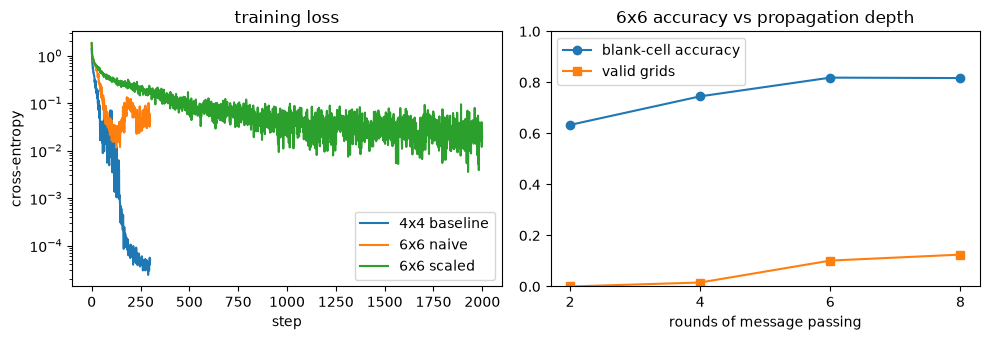

In [10]:
import matplotlib.pyplot as plt

fig, (left, right) = plt.subplots(1, 2, figsize=(10, 3.5))
for name, (losses, _, _) in [
        ("4x4 baseline", baseline), ("6x6 naive", naive),
        ("6x6 scaled", scaled)]:
    left.plot(losses, label=name)
left.set_xlabel("step"), left.set_ylabel("cross-entropy")
left.set_yscale("log"), left.legend(), left.set_title("training loss")

rounds = sorted(sweep)
right.plot(rounds, [sweep[r][1] for r in rounds], "o-",
           label="blank-cell accuracy")
right.plot(rounds, [sweep[r][2] for r in rounds], "s-",
           label="valid grids")
right.set_xlabel("rounds of message passing"), right.set_xticks(rounds)
right.set_ylim(0, 1), right.legend()
right.set_title("6x6 accuracy vs propagation depth")
plt.tight_layout()
plt.show()

## Summary

The same compositional architecture — one shared cell `Network`, wired by
`sudoku` into a closed combinatorial map, trained through the execution
formula — carries from 4x4 to 6x6 unchanged; only the hyperparameters had
to scale, and they scale the same way at both sizes.

In [11]:
print(f"{'experiment':>14} {'blanks':>8} {'valid':>7}")
for name, (_, blank_acc, solved) in [
        ("4x4 baseline", baseline), ("4x4 tuned", tuned_4x4),
        ("6x6 naive", naive), ("6x6 scaled", scaled)]:
    print(f"{name:>14} {blank_acc:>8.0%} {solved:>7.0%}")

    experiment   blanks   valid
  4x4 baseline      86%     48%
     4x4 tuned      95%     93%
     6x6 naive      41%      0%
    6x6 scaled      89%     52%


The gap that remains at 6x6 is real: a valid grid needs *every* blank
right, so cell-level errors compound — the same reason exact solvers
backtrack. Two directions from here:

* **9x9**: `sudoku(3)` gives the 81-cell map with 20 peers per cell; the
  same solver builds and trains, but the width, rounds and data appetite
  keep growing — and serious 9x9 datasets (e.g. minimal 17-clue puzzles)
  are far harder than uniformly blanked grids,
* **decoding**: reading each cell independently through `decode_sudoku`
  wastes the joint structure in the logits; sequential decoding — commit
  to the most confident cell, re-inject it as a clue, run more rounds —
  turns the trained network into a propagation engine inside a search
  loop, which is how neural solvers close the last gap.